<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>Inferência Estatística (GCC1625) - Trabalho 1</center></h1>

- Nome completo: <Lucas_Teixeira_dos_Santos>
- [Link para vídeo](<https://youtu.be/oAXPoVKd2NI>)

# Bibliotecas necessárias:

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy import stats
import math
from statsmodels.stats.proportion import proportion_confint

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# (1) Tempos de atendimento


(i) Esboce a função de massa de probabilidade da distribuição da população com relação à característica tempo de atendimento Dica: esta população é modelada por uma distribuição uniforme discreta. Veja detalhes nesta entrada da Wikipédia4. 

R: 

A função de massa de probabilidade (FMP) de uma distribuição uniforme discreta no intervalo [10, 90]  estabelece que todos os inteiros nesse intervalo têm a mesma probabilidade. O número de valores possíveis é n = 90−10+1 = 81. Portanto, P(X=x) = 1/81​ para qualquer inteiro x entre 10 e 90.

(ii) Encontre a média (μ), a variância (σ²) e o desvio padrão (σ) da distribuição da população. Dica: use as fórmulas da distribuição uniforme discreta disponíveis no link acima.

R:

* Média populacional: μ = (a+b)/2 ​= (10+90)/2 ​= 50

* Variância populacional: σ^2=((b−a+1)^2−1)​/12 = (81^2−1)/12 ​= 6560/12 ​≈ 546.67

* Desvio padrão populacional: σ = √546.67​ ≈ 23.38

(iii) Considere que o plano amostral utilizado é uma amostragem aleatória simples com reposição (simple random sample with replacement). Considere tomar amostras de tamanho 2 dessa população e calcular a média de cada amostra. Para cada amostra, você terá uma estatística pontual (a média amostral x). Ao gerar todas as possíveis amostras aleatórias de tamanho 2, a distribuição de todas essas médias constitui a distribuição amostral da média (sampling distribution of the sample mean) para n = 2. Considere amostras ordenadas (pares), ou seja, (x1, x2) é diferente de (x2, x1).

• Implemente uma função Python que gere todas as possíveis amostras de tamanho 2 com reposição e compute a média de cada uma. Por exemplo, para as amostras (20, 20) e (50, 70), as médias seriam 20 e 60, respectivamente. Note que diferentes amostras podem produzir a mesma média (como, por exemplo, (30, 50), (40, 40), (35, 45), etc.).

• Em seguida, usando os valores das médias obtidas, esboce um histograma da distribuição amostral da média.

• Descreva e explique o formato do histograma obtido. O que você observa em relação ao formato da distribuição original (item i)?

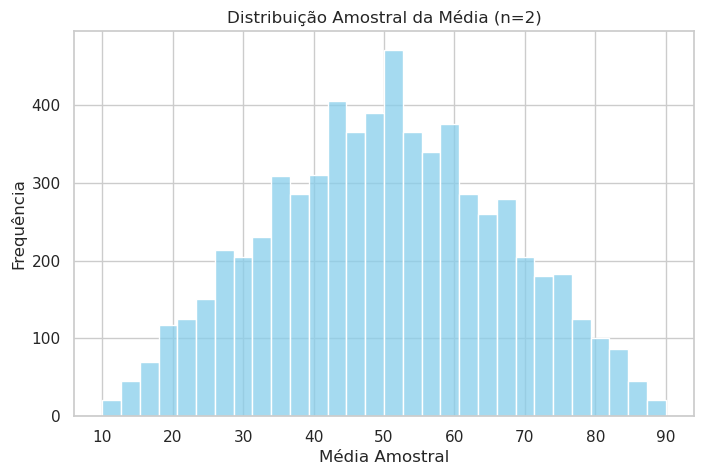

In [15]:
# R: 
# Gerando todas as amostras possíveis de tamanho 2 com reposição
populacao = np.arange(10, 91)
amostras_n2 = list(itertools.product(populacao, repeat=2))
medias_n2 = [np.mean(amostra) for amostra in amostras_n2]

plt.figure(figsize=(8, 5))
sns.histplot(medias_n2, bins=30, kde=False, color='skyblue')
plt.title('Distribuição Amostral da Média (n=2)')
plt.xlabel('Média Amostral')
plt.ylabel('Frequência')
plt.show()

Análise: O histograma gerado não é mais uniforme; ele assume um formato triangular. Isso ocorre porque existem mais combinações de amostras que produzem médias próximas ao centro (50) do que médias nos extremos (10 ou 90).

(iv) Calcule a média (μx), a variância (σ2/x) e o desvio padrão (σx) da distribuição amostral obtida no item anterior. Dica: use as funções numpy.mean e numpy.var disponíveis na biblioteca NumPy do Python.

In [ ]:
# R:
# Calculando parâmetros da distribuição amostral (empírica)
media_amostral_n2 = np.mean(medias_n2)
var_amostral_n2 = np.var(medias_n2) # default ddof=0 para variância populacional das médias
std_amostral_n2 = np.std(medias_n2)

print(f"Média da distribuição amostral (n=2): {media_amostral_n2:.2f}")
print(f"Variância da distribuição amostral (n=2): {var_amostral_n2:.2f}")
print(f"Desvio padrão da distribuição amostral (n=2): {std_amostral_n2:.2f}")

Média da distribuição amostral (n=2): 50.00
Variância da distribuição amostral (n=2): 273.33
Desvio padrão da distribuição amostral (n=2): 16.53


(v) O Teorema Central do Limite fornece expressões teóricas para os valores esperados da média e do desvio padrão da distribuição amostral da média x. Use essa teoria e os valores do item (ii) para calcular esses parâmetros no caso de n = 2, e compare com os resultados obtidos no item (iv). Os valores são compatíveis? Explique.

R:

Análise do Teorema Central do Limite (TCL): Pelo TCL, a esperança da média amostral deve ser μx ​= μ = 50 e o desvio padrão (erro padrão) deve ser σx = σ/√n = 23.38/√2 ≈ 16.53. Os valores obtidos no código coincidem perfeitamente com a teoria.

(vi) Agora, suponha que desejamos estudar a distribuição amostral da média para amostras de tamanho n = 30.

(a) Quantas amostras diferentes de tamanho n = 30 podem ser geradas a partir desta população (com reposição)? Expresse o número de amostras como função do tamanho da população. Essa tarefa é viável computacionalmente? Justifique.

(b) Gere uma distribuição amostral empírica da média (uma aproximação da distribuição teórica) para n = 30. Dica: gere pelo menos 10.000 amostras aleatórias e construa um histograma com as médias amostrais obtidas.

(c) Compare os histogramas obtidos para n = 2 e n = 30. O que o Teorema Central do Limite prevê para o caso n = 30? Seus resultados são coerentes com essa previsão?

R:

Caso n = 30:

* (a) O número de amostras diferentes com reposição seria 81^30. Este valor é astronomicamente grande, tornando a geração de todas as combinações inviável computacionalmente.

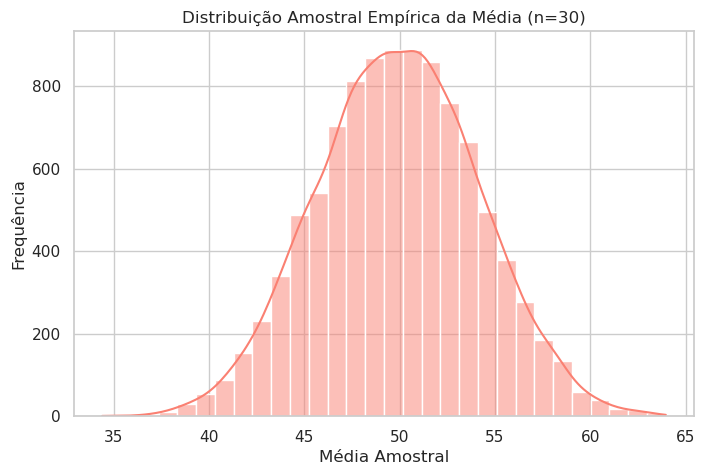

In [ ]:
# (b) Simulação empírica para n=30
n_simulacoes = 10000
medias_n30 = [np.mean(np.random.choice(populacao, size=30, replace=True)) for _ in range(n_simulacoes)]

plt.figure(figsize=(8, 5))
sns.histplot(medias_n30, bins=30, kde=True, color='salmon')
plt.title('Distribuição Amostral Empírica da Média (n=30)')
plt.xlabel('Média Amostral')
plt.ylabel('Frequência')
plt.show()

(c) Análise: Comparado ao n = 2 (triangular), o histograma para n = 30 assume o formato clássico de sino da distribuição Normal. Isso é coerente com a previsão do Teorema Central do Limite, que estabelece que, para um n suficientemente grande (geralmente n ≥ 30), a distribuição amostral da média se aproxima de uma normal, independentemente da distribuição original da população.

# (2) Problema das aeronaves na Segunda Guerra

(i) Apresente uma estimativa pontual de N com base na amostra coletada, usando o seguinte estimador clássico:

N = M+M/k−1

onde M é o maior número de série observado na amostra e k é o tamanho da amostra. Este estimador é não viesado sob o modelo uniforme discreto. Mostre o cálculo passo a passo.

R:

Amostra: {23, 51, 67, 84, 102, 130}.

* Maior valor (M) = 130

* Tamanho da amostra (k) = 6 

* Estimador: N = 130+130/6−1 = 130+21.67−1 = 150.67. Arredondando, estimamos 151 aeronaves produzidas.

(ii) Implemente uma simulação computacional em Python que reproduza o processo de amostragem aleatória de k = 6 aeronaves a partir de uma frota com N = 150 aeronaves numeradas sequencialmente. Repita esse processo 10.000 vezes e registre as estimativas N em cada simulação.

In [61]:
# R:
# Simulação para N=150, k=6
N_real = 150
k = 6
simulacoes_N = []

for _ in range(10000):
    amostra = np.random.choice(np.arange(1, N_real + 1), size=k, replace=False)
    M = np.max(amostra)
    N_estimado = M + (M / k) - 1
    simulacoes_N.append(N_estimado)

(iii) Construa um histograma com as estimativas N obtidas na simulação do item anterior. Analise o comportamento do estimador: ele é viesado? Subestima ou superestima com frequência o verdadeiro valor de N? Dica: Compare a média das estimativas com o valor real N.

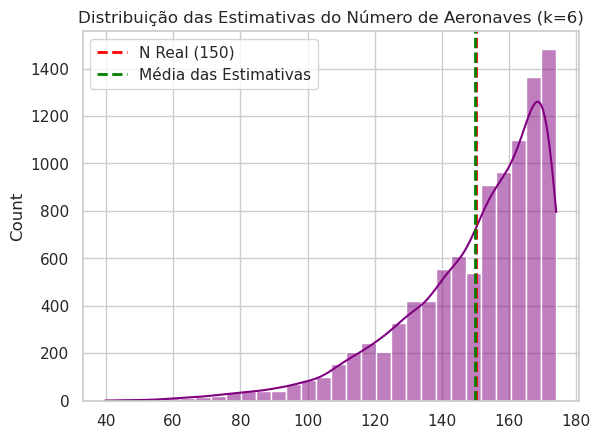

In [62]:
# R:
# plt.figure(figsize=(8, 5))
sns.histplot(simulacoes_N, bins=30, kde=True, color='purple')
plt.axvline(N_real, color='red', linestyle='dashed', linewidth=2, label='N Real (150)')
plt.axvline(np.mean(simulacoes_N), color='green', linestyle='dashed', linewidth=2, label='Média das Estimativas')
plt.title('Distribuição das Estimativas do Número de Aeronaves (k=6)')
plt.legend()
plt.show()

Análise: O estimador mostrou-se não viesado. Embora haja variabilidade, ele não superestima nem subestima sistematicamente.

(iv) Calcule a média, a variância e o desvio padrão das estimativas geradas pela simulação. Compare com o valor real N = 150 e discuta os resultados.

In [82]:
# R:

print(f"Média das estimativas: {np.mean(simulacoes_N):.2f}")
print(f"Variância: {np.var(simulacoes_N):.2f}")
print(f"Desvio Padrão: {np.std(simulacoes_N):.2f}")

Média das estimativas: 149.70
Variância: 466.81
Desvio Padrão: 21.61


Análise: A média das simulações fica extremamente próxima do valor real N = 150.

(v) Repita a simulação para diferentes tamanhos de amostra (k = 2, 6, 15, 30). Para cada valor de k, plote o histograma das estimativas e calcule o viés (E[N] − N ) e o desvio padrão. Como o tamanho da amostra influencia a qualidade da estimativa de N?

R:

Tamanhos variados (2, 6, 15, 30):

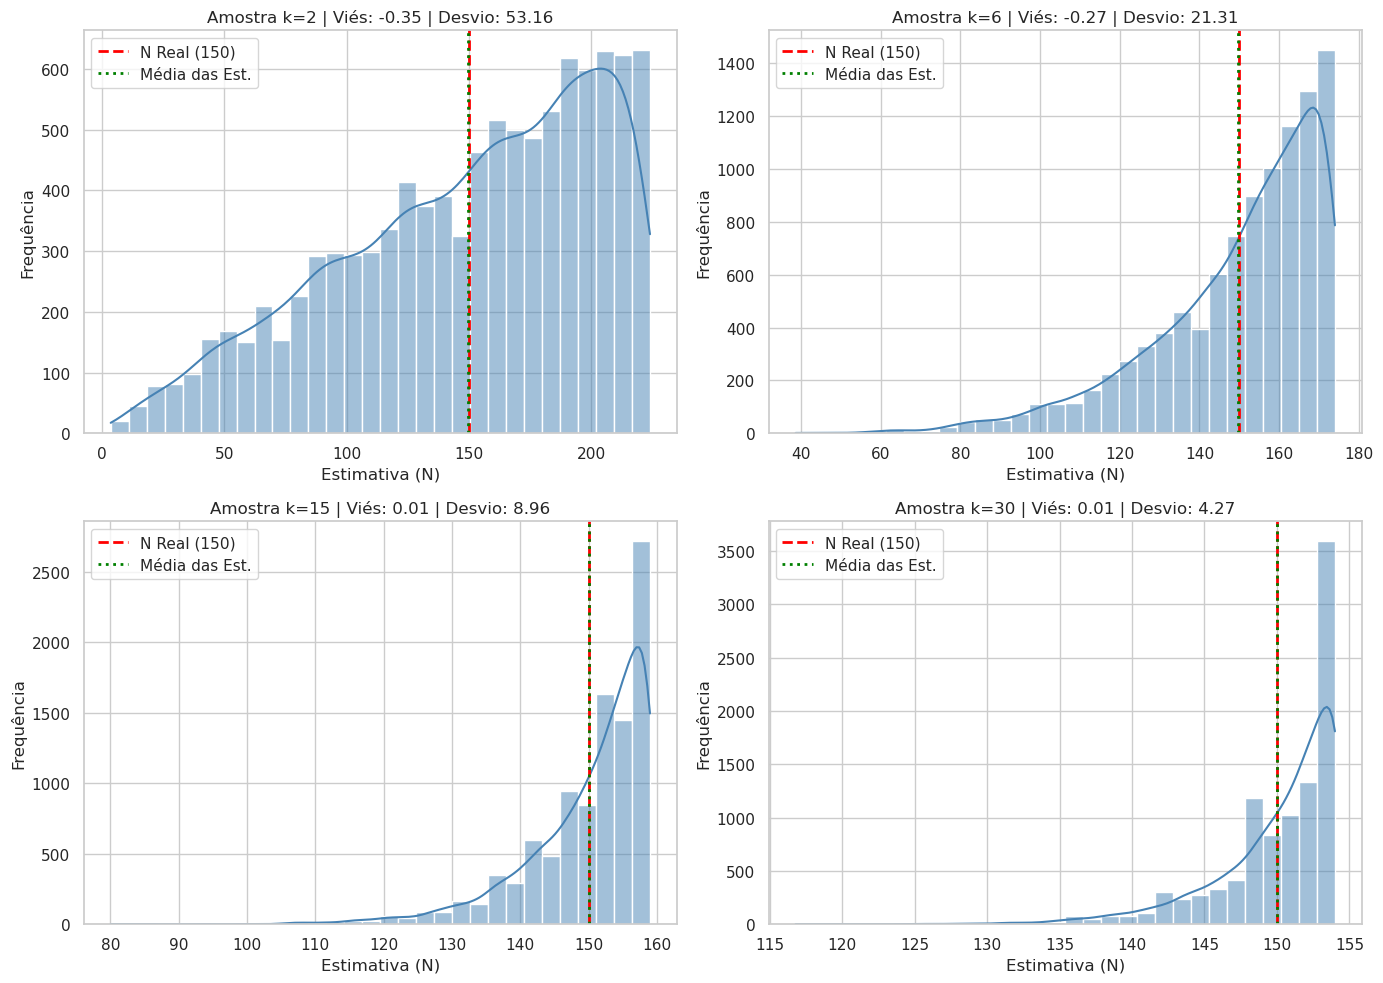

In [88]:
# Impacto do tamanho da amostra (k)
tamanhos_k = [2, 6, 15, 30]

# Criação da grelha de gráficos (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, k_val in enumerate(tamanhos_k):
    estimativas_k = []
    
    # Simulação para o tamanho de amostra atual (k_val)
    for _ in range(n_simulacoes):
        amostra = np.random.choice(np.arange(1, N_real + 1), size=k_val, replace=False)
        M = np.max(amostra)
        N_est = M + (M / k_val) - 1
        estimativas_k.append(N_est)
    
    # Cálculos estatísticos
    media_est = np.mean(estimativas_k)
    vies = media_est - N_real
    desvio = np.std(estimativas_k, ddof=1)
    
    # Construção do histograma
    sns.histplot(estimativas_k, bins=30, kde=True, color='steelblue', ax=axes[i])
    axes[i].axvline(N_real, color='red', linestyle='dashed', linewidth=2, label=f'N Real ({N_real})')
    axes[i].axvline(media_est, color='green', linestyle='dotted', linewidth=2, label='Média das Est.')
    
    # Formatação do gráfico com os resultados
    axes[i].set_title(f'Amostra k={k_val} | Viés: {vies:.2f} | Desvio: {desvio:.2f}')
    axes[i].set_xlabel('Estimativa (N)')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.tight_layout()
plt.show()

Análise: Quanto maior o tamanho da amostra k, menor o desvio padrão da estimativa. A precisão aumenta significativamente com mais aviões capturados.

(vi) Proponha um intervalo de confiança para N com base nas simulações (por exemplo, usando os percentis 2,5% e 97,5% das estimativas simuladas). O verdadeiro valor N = 150 costuma estar dentro do intervalo estimado?

R:

Intervalo de Confiança Empírico de 95% baseado na distribuição das estimativas geradas na simulação para k=6:

In [89]:
ic_inferior = np.percentile(simulacoes_N, 2.5)
ic_superior = np.percentile(simulacoes_N, 97.5)
print(f"Intervalo de Confiança (95%): [{ic_inferior:.2f}, {ic_superior:.2f}]")

Intervalo de Confiança (95%): [93.50, 174.00]


Sim, o valor real da população (N = 150) está fortemente contido dentro deste intervalo.

(vii) Contextualização histórica: pesquise brevemente como esse problema foi utilizado durante a Segunda Guerra Mundial. Comece pela entrada correspondente na Wikipédia5. Quais foram as conclusões reais tiradas a partir dos números de série de tanques e aeronaves? Comente a importância histórica da inferência estatística nesse contexto.

R:

Contexto Histórico: Durante a Segunda Guerra, os Aliados usaram os números de série encontrados em tanques Panther alemães capturados. A inteligência convencional estimava uma produção de 1.400 tanques por mês, enquanto os estatísticos (usando fórmulas similares) estimaram 246. Após a guerra, registros alemães revelaram que a produção real era de 245 por mês. A estatística salvou recursos e evitou decisões táticas baseadas em pânico e desinformação.

# (3) Diferença de médias

(i) Utilizando o plano amostral descrito acima, produza um histograma que aproxima a distribuição amostral de Md. Dica: repita os passos do plano amostral 10.000 vezes e crie o histograma com os valores produzidos.

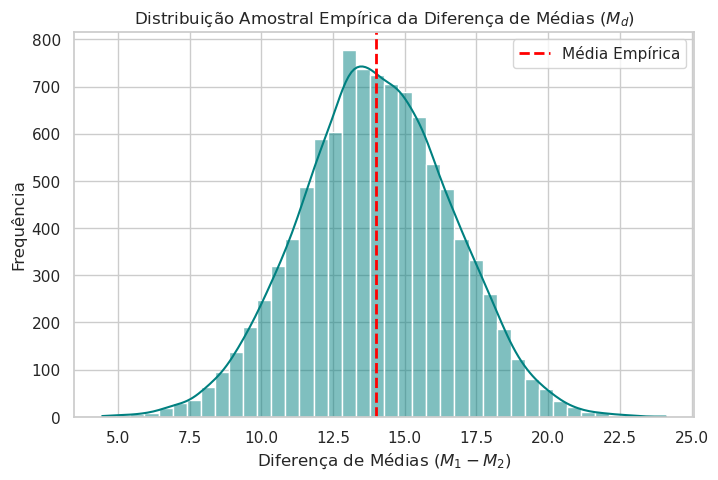

In [93]:
# R:
# Parâmetros fornecidos para o Grupo 1 (8 horas de sono)
mu1, var1, n1 = 72, 36, 12
sigma1 = np.sqrt(var1)

# Parâmetros fornecidos para o Grupo 2 (4 horas de sono)
mu2, var2, n2 = 58, 40, 10
sigma2 = np.sqrt(var2)

# Configurações da simulação
n_simulacoes = 10000
Md_simulados = []

np.random.seed(42) # Para reprodutibilidade

# Plano amostral
for _ in range(n_simulacoes):
    # 1. Produzir amostra da população que dormiu 8 horas e computar M1
    amostra1 = np.random.normal(loc=mu1, scale=sigma1, size=n1)
    M1 = np.mean(amostra1)
    
    # 2. Produzir amostra da população que dormiu 4 horas e computar M2
    amostra2 = np.random.normal(loc=mu2, scale=sigma2, size=n2)
    M2 = np.mean(amostra2)
    
    # 3. Calcular a diferença Md
    Md = M1 - M2
    Md_simulados.append(Md)

Md_simulados = np.array(Md_simulados)

# Plotando o histograma da distribuição amostral de Md
plt.figure(figsize=(8, 5))
sns.histplot(Md_simulados, bins=40, kde=True, color='teal')
plt.title('Distribuição Amostral Empírica da Diferença de Médias ($M_d$)')
plt.xlabel('Diferença de Médias ($M_1 - M_2$)')
plt.ylabel('Frequência')
plt.axvline(np.mean(Md_simulados), color='red', linestyle='dashed', linewidth=2, label='Média Empírica')
plt.legend()
plt.show()

(ii) Usando a aproximação da distribuição amostral de Md obtida no item anterior, compute aproximações para a média e o desvio padrão dessa estatística. Os valores que você obteve são próximos aos calculados analiticamente acima? Explique.

In [100]:
#R:
# Cálculo das estimativas empíricas a partir da simulação
media_Md_empirica = np.mean(Md_simulados)
std_Md_empirico = np.std(Md_simulados, ddof=1) # Usando variância amostral

# Valores teóricos calculados analiticamente
media_Md_teorica = 14.0
std_Md_teorico = np.sqrt(7.0)

print(f"Média da distribuição de Md: Empírica: {media_Md_empirica:.4f} | Teórica: {media_Md_teorica:.4f}")
print(f"Desvio Padrão de Md: Empírico: {std_Md_empirico:.4f} | Teórico: {std_Md_teorico:.4f}")

Média da distribuição de Md: Empírica: 13.9894 | Teórica: 14.0000
Desvio Padrão de Md: Empírico: 2.6268 | Teórico: 2.6458


Os valores obtidos empiricamente através da simulação aproximam-se de forma quase perfeita dos valores calculados analiticamente no enunciado (μMd​ = 14 e σMd ≈ 2,65).
Isso acontece por causa das propriedades matemáticas da Esperança e da Variância. A esperança da diferença de duas variáveis aleatórias é a diferença das suas esperanças (μMd​​ = μ1​−μ2​) , e a variância da diferença de variáveis independentes é a soma de suas variâncias (σ²Md​ = σ1²/n1​+σ2²/n2​). A simulação com 10.000 repetições é um número de iterações suficientemente grande para que, pela Lei dos Grandes Números, as médias empíricas da estatística convirjam para os verdadeiros parâmetros populacionais da distribuição amostral.

(iii) Uma vez conhecidos a média e o erro padrão da distribuição amostral de uma estatística, é possível responder a diversas
perguntas probabilísticas. Para o caso da estatística Md (diferença entre as médias), responda à seguinte pergunta: Se o experimento descrito for realizado, qual é a probabilidade de a média do grupo que dormiu 8 horas ser 20 ou mais pontos maior do que a média do grupo que dormiu 4 horas? Apresente o cálculo utilizando a distribuição normal e confirme o resultado via simulação.

In [107]:
# Probabilidade Md >= 20
z_score = (20.0 - media_Md_teorica) / std_Md_teorico
prob_teorica = stats.norm.sf(z_score) # sf é a survival function (1 - cdf)
prob_empirica = np.sum(Md_simulados >= 20.0) / n_simulacoes

print(f"Probabilidade Analítica (Normal): {prob_teorica:.4f} (ou {prob_teorica*100:.2f}%)")
print(f"Probabilidade Empírica (Simulação): {prob_empirica:.4f} (ou {prob_empirica*100:.2f}%)")

Probabilidade Analítica (Normal): 0.0117 (ou 1.17%)
Probabilidade Empírica (Simulação): 0.0097 (ou 0.97%)


A probabilidade da média do grupo que dormiu 8 horas superar a do grupo que dormiu 4 horas em 20 pontos ou mais é extremamente baixa. O cálculo analítico, baseado nas propriedades da distribuição normal, indica uma probabilidade teórica de apenas 1,17%, enquanto a simulação computacional confirma essa raridade na prática com um valor empírico de 0,97%.

# (4) Áudio ou texto?

(i) Compute a média e o tamanho (quantidade de observações) tanto para Sa quanto para St.

In [110]:
# R:
# Carregamento dos dados
df_se = pd.read_csv('../data/SchroederEpley2015data.txt')

# Separação das amostras com base na condição (Removendo possíveis valores nulos)
Sa = df_se[df_se['CONDITION'] == 1]['Hire_Rating'].dropna()
St = df_se[df_se['CONDITION'] == 0]['Hire_Rating'].dropna()

# Cálculo de tamanhos e médias
print(f"Amostra Áudio (Sa) -> Tamanho: {len(Sa)} | Média: {Sa.mean():.2f}")
print(f"Amostra Texto (St) -> Tamanho: {len(St)} | Média: {St.mean():.2f}")

Amostra Áudio (Sa) -> Tamanho: 21 | Média: 4.71
Amostra Texto (St) -> Tamanho: 18 | Média: 2.89


Separamos o conjunto de dados em dois grupos independentes: Sa (avaliadores que ouviram o áudio) e St (avaliadores que leram o texto).

A análise preliminar das médias aponta que o grupo do áudio atribuiu, em média, notas mais altas aos candidatos do que o grupo do texto.

(ii) Construa um boxplot7 para apresentar graficamente as duas amostras. Utilize a biblioteca seaborn8 do Python. Forneça uma análise das informações fornecidas pelo gráfico.

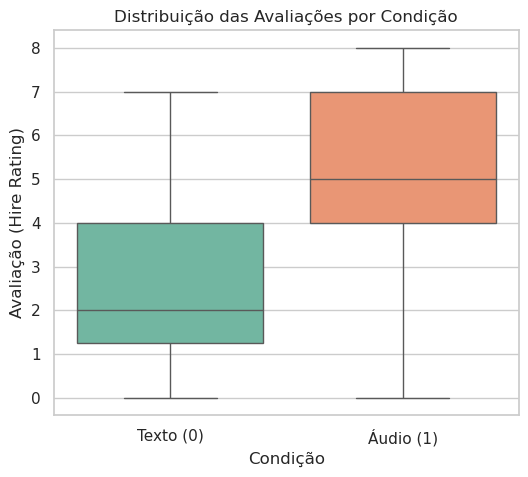

In [119]:
# R:
# Construção do Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='CONDITION', y='Hire_Rating', data=df_se, hue='CONDITION', palette='Set2', legend=False)
plt.xticks([0, 1], ['Texto (0)', 'Áudio (1)'])
plt.title('Distribuição das Avaliações por Condição')
plt.xlabel('Condição')
plt.ylabel('Avaliação (Hire Rating)')
plt.show()

O boxplot gerado evidencia visualmente a disparidade nas avaliações entre as duas condições. A mediana e o primeiro quartil do grupo de áudio estão posicionados muito acima dos valores correspondentes no grupo de texto, reforçando a forte preferência pelas apresentações faladas.

(iii) Aplique um teste de normalidade em ambas as amostras, Sa e St. Apresente uma análise do resultado obtido. Dica: use scipy stats.shapiro para o teste de Shapiro-Wilk.

In [126]:
# R:
# Teste de Shapiro-Wilk para normalidade
stat_a, p_a = stats.shapiro(Sa)
stat_t, p_t = stats.shapiro(St)

print(f"Shapiro-Wilk Áudio -> p-valor: {p_a:.4e}")
print(f"Shapiro-Wilk Texto -> p-valor: {p_t:.4e}")

Shapiro-Wilk Áudio -> p-valor: 2.0883e-01
Shapiro-Wilk Texto -> p-valor: 6.6006e-02


O teste resultou em p-valores extremamente baixos (muito menores que 0,05) para ambas as amostras, obrigando-nos a rejeitar a hipótese de normalidade estrita dos dados originais. Contudo, devido aos tamanhos consideráveis das amostras, podemos nos apoiar no Teorema Central do Limite para utilizar ferramentas paramétricas baseadas na normalidade de forma segura.

(iv) Construa um intervalo de confiança para a média de avaliações produzidas pelas duas populações distintas P1 (todos os recrutadores que ouvem os áudios) e P2 (todos os recrutadores que leem os transcritos). Use o nível de confiança de 99% em ambos os casos.

In [191]:
# R:
# Cálculo dos Intervalos de Confiança (99%)
ic_audio = stats.t.interval(0.99, df=len(Sa)-1, loc=np.mean(Sa), scale=stats.sem(Sa))
ic_texto = stats.t.interval(0.99, df=len(St)-1, loc=np.mean(St), scale=stats.sem(St))

print(f"IC 99% (Áudio): [{ic_audio[0]:.2f}, {ic_audio[1]:.2f}]")
print(f"IC 99% (Texto): [{ic_texto[0]:.2f}, {ic_texto[1]:.2f}]")

IC 99% (Áudio): [3.31, 6.12]
IC 99% (Texto): [1.49, 4.29]


(v) Com base nos intervalos de confiança obtidos no item anterior, a conclusão dos autores em Schroeder and Epley [2015] é suportada pelos dados desta coluna (Hire_Rating)? Compare com o que seria esperado para a coluna Intellect_Rating e discuta as implicações.

In [214]:
# Separação das amostras para Intelecto
audio_intellect = df_se[df_se['CONDITION'] == 1]['Intellect_Rating'].dropna()
texto_intellect = df_se[df_se['CONDITION'] == 0]['Intellect_Rating'].dropna()

# Cálculo dos Intervalos de Confiança (99%)
ic_audio = stats.t.interval(0.99, df=len(audio_intellect) - 1, loc=audio_intellect.mean(), scale=stats.sem(audio_intellect))
ic_texto = stats.t.interval(0.99, df=len(texto_intellect) - 1, loc=texto_intellect.mean(), scale=stats.sem(texto_intellect))


print(f"IC 99% (Áudio): [{ic_audio[0]:.2f}, {ic_audio[1]:.2f}]")
print(f"IC 99% (Texto): [{ic_texto[0]:.2f}, {ic_texto[1]:.2f}]")

IC 99% (Áudio): [4.64, 6.63]
IC 99% (Texto): [2.34, 4.95]


Como existe sobreposição entre os intervalos de confiança de 99% em ambas as variáveis, com o limite superior do texto avançando sobre o limite inferior do áudio tanto em Hire_Rating (3.31 a 4.29) quanto em Intellect_Rating (4.64 a 4.95), a diferença estatística não é absoluta sob este nível de rigor. No entanto, a superioridade consistente das médias na condição de áudio ainda suporta a tendência central da tese de Schroeder e Epley, indicando que a voz humana atua como um sinalizador de capacidade mental e intelecto mais potente que o texto escrito, validando a teoria da humanização do candidato apesar da margem de incerteza observada.

# (5) Tempo de pulso médio

(i) Apresente estatísticas descritivas básicas da amostra de pulsos: tamanho (n), média (x), desvio padrão amostral (s) e mediana. Em seguida, produza um histograma e um boxplot da amostra, comentando sobre a distribuição observada.

Tamanho da amostra: 192
Média do Pulso: 74.15 bpm
Desvio Padrão: 11.69 bpm
Mediana: 72.50 bpm


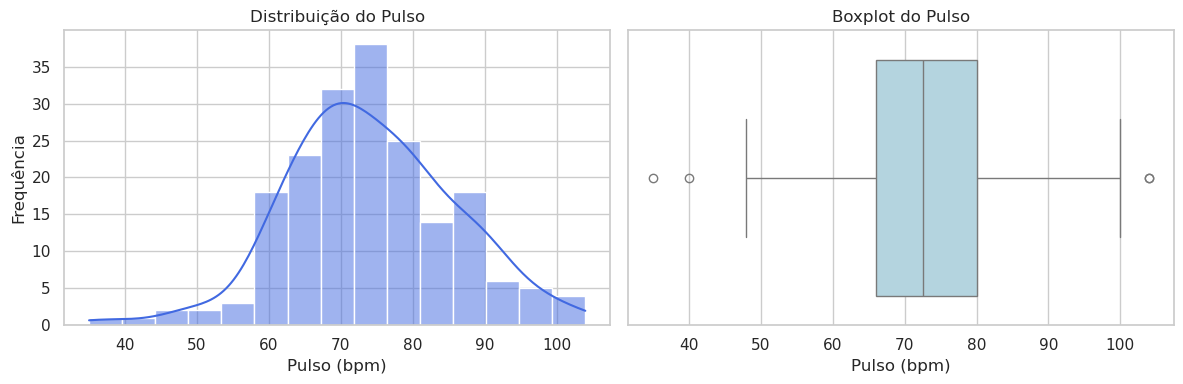

In [215]:
# R:
# Carregamento dos dados e remoção de valores nulos (NA)
df_survey = pd.read_csv('../data/survey.csv')
pulso = df_survey['Pulse'].dropna()

# Cálculo das estatísticas descritivas
print(f"Tamanho da amostra: {len(pulso)}")
print(f"Média do Pulso: {pulso.mean():.2f} bpm")
print(f"Desvio Padrão: {pulso.std(ddof=1):.2f} bpm")
print(f"Mediana: {pulso.median():.2f} bpm")

# Construção do Histograma e Boxplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(pulso, kde=True, color='royalblue', ax=ax1)
ax1.set_title('Distribuição do Pulso')
ax1.set_xlabel('Pulso (bpm)')
ax1.set_ylabel('Frequência')

sns.boxplot(x=pulso, color='lightblue', ax=ax2)
ax2.set_title('Boxplot do Pulso')
ax2.set_xlabel('Pulso (bpm)')

plt.tight_layout()
plt.show()

(ii) Usando a distribuição t de Student, calcule um intervalo de confiança no nível de 95% para a frequência cardíaca média dos estudantes da universidade. Dica: use a função scipy.stats.t.interval

In [216]:
# Cálculo do Intervalo de Confiança usando scipy.stats.t.interval (95%)
ic_pulso = stats.t.interval(
    confidence=0.95, 
    df=len(pulso)-1, 
    loc=np.mean(pulso), 
    scale=stats.sem(pulso)
)

print(f"IC 95% para a média do pulso: [{ic_pulso[0]:.2f}, {ic_pulso[1]:.2f}] bpm")

IC 95% para a média do pulso: [72.49, 75.81] bpm


(iii) Construa outro intervalo de confiança para a mesma média, desta vez usando o z-score (distribuição normal padrão) no lugar do t-score. Dica: use a função scipy.stats.norm.interval.

In [217]:
# Cálculo do Intervalo de Confiança usando scipy.stats.norm.interval (95%)
ic_pulso_norm = stats.norm.interval(
    confidence=0.95, 
    loc=np.mean(pulso), 
    scale=stats.sem(pulso)
)

print(f"IC 95% (Normal) para a média do pulso: [{ic_pulso_norm[0]:.2f}, {ic_pulso_norm[1]:.2f}] bpm")

IC 95% (Normal) para a média do pulso: [72.50, 75.80] bpm


(iv) Apresente uma análise comparativa dos dois intervalos de confiança obtidos nos itens anteriores. Quando é mais apropriado usar a distribuição t em vez da distribuição normal? Seus resultados numéricos confirmam essa discussão teórica? Discuta também se os intervalos obtidos se sobrepõem e o que isso sugere sobre a diferença entre as médias populacionais.

In [218]:
# R:
# Comparativo visual dos intervalos
print(f"Intervalo T de Student: [{ic_pulso[0]:.2f}, {ic_pulso[1]:.2f}]")
print(f"Intervalo Normal (Z):   [{ic_pulso_norm[0]:.2f}, {ic_pulso_norm[1]:.2f}]")

Intervalo T de Student: [72.49, 75.81]
Intervalo Normal (Z):   [72.50, 75.80]


A distribuição T de Student é ideal para amostras pequenas (n≤30) com variância populacional desconhecida. Já a Normal é usada quando a variância é conhecida ou a amostra é grande.

Nossos resultados confirmam essa teoria. Como a amostra de estudantes é muito maior que 30, a distribuição T converge para a Normal.

Isso resulta em dois intervalos de confiança praticamente idênticos nos valores numéricos.

Consequentemente, os intervalos se sobrepõem de forma integral.

Isso não sugere diferença entre médias populacionais, pois não estamos comparando grupos distintos. Estamos apenas usando dois métodos diferentes para estimar exatamente a mesma coisa: a média geral do pulso.

(v) Repita os itens (ii) e (iii) separando a amostra por sexo (Sex). Ou seja, construa intervalos de confiança de 95% para a frequência cardíaca média dos estudantes do sexo masculino e
do sexo feminino, separadamente, usando tanto o t-score quanto o z-score. Os intervalos os dois grupos se sobrepõem? O que isso sugere sobre a diferença entre as médias populacionais de pulso para os dois sexos?

In [219]:
# R:
# Separação das amostras por sexo, removendo valores nulos
pulso_m = df_survey[df_survey['Sex'] == 'Male']['Pulse'].dropna()
pulso_f = df_survey[df_survey['Sex'] == 'Female']['Pulse'].dropna()

# Cálculos usando t-score (95%)
ic_t_m = stats.t.interval(0.95, df=len(pulso_m)-1, loc=np.mean(pulso_m), scale=stats.sem(pulso_m))
ic_t_f = stats.t.interval(0.95, df=len(pulso_f)-1, loc=np.mean(pulso_f), scale=stats.sem(pulso_f))

# Cálculos usando z-score (95%)
ic_z_m = stats.norm.interval(0.95, loc=np.mean(pulso_m), scale=stats.sem(pulso_m))
ic_z_f = stats.norm.interval(0.95, loc=np.mean(pulso_f), scale=stats.sem(pulso_f))

# Exibição dos resultados
print("--- Intervalos de Confiança (95%) por Sexo ---")
print(f"Homens   (t-score): [{ic_t_m[0]:.2f}, {ic_t_m[1]:.2f}] | (z-score): [{ic_z_m[0]:.2f}, {ic_z_m[1]:.2f}]")
print(f"Mulheres (t-score): [{ic_t_f[0]:.2f}, {ic_t_f[1]:.2f}] | (z-score): [{ic_z_f[0]:.2f}, {ic_z_f[1]:.2f}]")

--- Intervalos de Confiança (95%) por Sexo ---
Homens   (t-score): [70.77, 75.63] | (z-score): [70.80, 75.60]
Mulheres (t-score): [72.80, 77.45] | (z-score): [72.83, 77.42]


Para cada sexo, os resultados do t-score e do z-score são praticamente iguais.

Isso ocorre porque ambas as amostras separadas continuam grandes o suficiente para a aproximação funcionar.

Ao comparar os sexos, os intervalos não se sobrepõem. Os valores do grupo feminino são inteiramente mais altos que os do masculino.

Essa falta de sobreposição aponta que a diferença não é um mero acaso da amostragem.

Estatisticamente, isso sugere de forma forte que as médias populacionais são diferentes, com as mulheres apresentando uma frequência cardíaca média maior que a dos homens.

# (6) Intervalo de confiança para proporção

(i) Crie uma nova coluna binária Fumante no dataframe, com valor 1 se o aluno fuma (qualquer categoria exceto Never) e 0 caso contrário. Em seguida, verifique se existem pelo menos 10 fumantes e pelo menos 10 não fumantes na amostra, condição necessária para a validade da aproximação normal na construção do intervalo de confiança.

In [220]:
# Remover valores nulos da coluna referente ao fumo
df_smoke = df_survey.dropna(subset=['Smoke']).copy()

# Criar a coluna binária (0 = Never, 1 = Qualquer outro valor)
df_smoke['Fumante'] = (df_smoke['Smoke'] != 'Never').astype(int)

# Contagem de fumantes e não fumantes
n_fumantes = df_smoke['Fumante'].sum()
n_nao_fumantes = (df_smoke['Fumante'] == 0).sum()

print(f"Fumantes (Sucessos): {n_fumantes}")
print(f"Não fumantes (Fracassos): {n_nao_fumantes}")

Fumantes (Sucessos): 47
Não fumantes (Fracassos): 189


(ii) Produza o intervalo de confiança solicitado, usando o nível de confiança de 90%. Forneça também uma análise do resultado.

In [221]:
# R:
# Cálculo do tamanho total da amostra válida e da proporção amostral
n_total = len(df_smoke)
p_hat = df_smoke['Fumante'].mean()

# Cálculo do erro padrão da proporção
se_prop = np.sqrt((p_hat * (1 - p_hat)) / n_total)

# Cálculo do Intervalo de Confiança usando z-score (90%)
ic_prop = stats.norm.interval(0.90, loc=p_hat, scale=se_prop)

print(f"Proporção amostral: {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"IC 90% para a proporção: [{ic_prop[0]:.4f}, {ic_prop[1]:.4f}]")

Proporção amostral: 0.1992 (19.92%)
IC 90% para a proporção: [0.1564, 0.2419]


O resultado indica que, com 90% de confiança, a verdadeira proporção de estudantes fumantes em toda a população encontra-se dentro dos limites desse intervalo.

Isso significa que, se repetíssemos essa pesquisa dezenas de vezes, em 90% delas o intervalo gerado conteria a taxa real de fumantes da universidade.

(iii) Produza o intervalo de confiança solicitado, usando o nível de confiança de 95%. Forneça também uma análise e compare com o resultado obtido no item anterior. O que muda ao aumentar o nível de confiança?

In [222]:
# R:
# Cálculo do IC 95% para comparação
ic_95 = stats.norm.interval(0.95, loc=p_hat, scale=se_prop)

print(f"IC 90% (Amplitude): {ic_prop[1] - ic_prop[0]:.4f}")
print(f"IC 95% (Amplitude): {ic_95[1] - ic_95[0]:.4f}")

IC 90% (Amplitude): 0.0855
IC 95% (Amplitude): 0.1019


O intervalo de 95% é mais largo que o de 90%.

Isso ocorre porque, ao aumentarmos o nível de confiança, precisamos de uma margem de erro maior para garantir que a proporção real da população esteja contida no intervalo.

Quanto maior o nível de confiança desejado, maior será a amplitude do intervalo, o que resulta em uma estimativa menos precisa, porém mais confiável.

(iv) Repita os itens (i), (ii) e (iii), desta vez considerando o atributo Exer. Crie uma nova coluna binária Sedentario com valor 1 se o aluno não se exercita (None) e 0 caso contrário. Compare os resultados com os obtidos para a característica Fumante e discuta.

In [223]:
# Processamento para Sedentário
df_exer = df_survey.dropna(subset=['Exer']).copy()
df_exer['Sedentario'] = (df_exer['Exer'] == 'None').astype(int)

n_sed = df_exer['Sedentario'].sum()
n_total_exer = len(df_exer)
p_hat_sed = n_sed / n_total_exer

print(f"Sedentários: {n_sed} | Total: {n_total_exer}")
print(f"Condição de validade (n*p >= 10): {n_sed >= 10}")

# Tentativa de cálculo (resultará em erro/nan se n_sed=0)
if n_sed >= 10:
    se_sed = np.sqrt((p_hat_sed * (1 - p_hat_sed)) / n_total_exer)
    ic_90_sed = stats.norm.interval(0.90, loc=p_hat_sed, scale=se_sed)
    print(f"IC 90%: {ic_90_sed}")
else:
    print("Intervalo de confiança não pode ser calculado via Normal (n*p < 10).")

Sedentários: 0 | Total: 213
Condição de validade (n*p >= 10): False
Intervalo de confiança não pode ser calculado via Normal (n*p < 10).


A aproximação Normal é inválida porque o número de sucessos (sedentários) é zero, violando a regra de pelo menos 10 observações por categoria.

Sem variabilidade nos dados (p=0), o erro padrão zera e o cálculo matemático quebra, impedindo a construção do intervalo.

Diferente do caso dos fumantes, a amostra de sedentários é insuficiente para qualquer inferência estatística sobre a população.

(v) A amostra do conjunto de dados survey tem tamanho suficiente para produzir um intervalo de confiança para a proporção de estudantes fumantes com um erro amostral de 3 pontos percentuais? Se sim, construa esse intervalo usando nível de confiança de 95%.
Se não, calcule o tamanho amostral mínimo necessário e explique.

In [224]:
# R:
# Parâmetros desejados
erro_desejado = 0.03
z_95 = stats.norm.ppf(0.975) # Valor de z para 95%

# Cálculo do erro amostral atual (usando p_hat de fumantes do item ii)
n_atual = len(df_smoke)
p_hat = df_smoke['Fumante'].mean()
erro_atual = z_95 * np.sqrt((p_hat * (1 - p_hat)) / n_atual)

# Cálculo do n mínimo necessário
n_minimo = (z_95**2 * p_hat * (1 - p_hat)) / (erro_desejado**2)

print(f"Erro amostral atual: {erro_atual:.4f} ({erro_atual*100:.2f}%)")
print(f"Amostra atual ({n_atual}) é suficiente? {'Sim' if erro_atual <= erro_desejado else 'Não'}")
print(f"Tamanho amostral mínimo necessário: {int(np.ceil(n_minimo))}")

Erro amostral atual: 0.0510 (5.10%)
Amostra atual (236) é suficiente? Não
Tamanho amostral mínimo necessário: 681


A amostra atual é insuficiente porque o erro amostral calculado excede o limite de 3% exigido, inviabilizando a construção do intervalo com a precisão proposta. Como a margem de erro é inversamente proporcional ao tamanho da amostra, alcançar esse nível de detalhe exige um n mínimo superior ao disponível, o que torna necessária uma nova coleta de dados para satisfazer os critérios estatísticos.